In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [98]:
#set professional color theme
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

viridis_colors = cm.viridis(np.linspace(0,1,5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [99]:
df = pd.read_csv(r"C:\Users\harsh\Downloads\DataCoSupplyChainDataset.csv", encoding="latin1")

In [100]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

Exploratory data Analysis(EDA)

In [101]:
#overview
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df.duplicated().sum())
print('\missing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [102]:
for col in df.columns:
    print(col)

Type
Days for shipping (real)
Days for shipment (scheduled)
Benefit per order
Sales per customer
Delivery Status
Late_delivery_risk
Category Id
Category Name
Customer City
Customer Country
Customer Email
Customer Fname
Customer Id
Customer Lname
Customer Password
Customer Segment
Customer State
Customer Street
Customer Zipcode
Department Id
Department Name
Latitude
Longitude
Market
Order City
Order Country
Order Customer Id
order date (DateOrders)
Order Id
Order Item Cardprod Id
Order Item Discount
Order Item Discount Rate
Order Item Id
Order Item Product Price
Order Item Profit Ratio
Order Item Quantity
Sales
Order Item Total
Order Profit Per Order
Order Region
Order State
Order Status
Order Zipcode
Product Card Id
Product Category Id
Product Description
Product Image
Product Name
Product Price
Product Status
shipping date (DateOrders)
Shipping Mode


In [103]:
import pandas as pd

# Data Cleaning

columns_to_drop = [
    'Product Description',
    'Product Image',
    'Customer Email',
    'Customer Password',
    'Customer Fname',
    'Customer Lname',
    'Customer Street',
    'Customer Zipcode',
    'Order Zipcode',
    'Longitude',
    'Latitude',
    'Order Item Cardprod Id',
    'Order Item Id',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Quantity',
    'Order Item Total',
    'Category Id',
    'Department Id',
    'Order Id',
    'Order Customer Id',
    'Customer Id',
    'Product Card Id',
    'Product Category Id',
    'Benefit per order',      # Same information as Order Profit Per Order
    'Product Status',          # Only one unique value
    'Customer City',
    'Order City',
    'Order Country',
    'Order State',
    'Customer State',
    'Market'
]

# Drop unnecessary columns
df = df.drop(columns=columns_to_drop, errors='ignore')

# Remove cancelled orders
df = df[df['Delivery Status'] != 'Shipping canceled']

# Convert date columns
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime(df[c], errors='coerce', dayfirst=False)

# Overview after cleaning
print("Rows, Columns:", df.shape)

print("\nMissing values (Top 5):")
print(df.isna().sum().sort_values(ascending=False).head(5))

Rows, Columns: (172765, 20)

Missing values (Top 5):
shipping date (DateOrders)    104239
order date (DateOrders)        68079
Days for shipping (real)           0
Product Price                      0
Product Name                       0
dtype: int64


In [104]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,NaT,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,NaT,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,NaT,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,NaT,Standard Class


In [105]:
#values counts for categorical columns with low cardinality
for col in df.columns:
    if df[col].nunique() < 10:
        print(f'\n{col} value counts:')
        print(df[col].value_counts())


Type value counts:
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value counts:
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value counts:
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value counts:
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value counts:
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value counts:
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value counts:
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Order Status value counts:
Order Status
COMPLETE  

In [106]:
# Calculate order processing time (in days)
df['Order Processing Time'] = (
    df['shipping date (DateOrders)'] - df['order date (DateOrders)']
).dt.days

# Calculate delay
df['Delays'] = (
    df['Order Processing Time'] - df['Days for shipment (scheduled)']
)

# Whether order is delayed
df['Is_Delayed'] = df['Delays'] > 0

# Extract month, day, and hour
df['order_month'] = df['order date (DateOrders)'].dt.month_name()
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour

# Summary
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,shipping date (DateOrders),Order Processing Time,Delays,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,104686,172765.000000,172765.000000,172765.000000,172765.000000,68526,20105.000000,20105.000000,104686.000000
mean,3.498596,2.933100,183.165948,0.572900,2016-06-18 06:17:21.150679040,0.120801,203.828493,22.032360,141.278595,2016-06-11 13:05:36.377725184,4.253519,0.970157,11.499264
min,0.000000,0.000000,7.490000,0.000000,2015-01-13 00:20:00,-2.750000,9.990000,-4274.979980,9.990000,2015-01-03 00:00:00,0.000000,-2.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,2015-09-26 02:46:00,0.080000,119.980003,7.030000,50.000000,2015-09-11 15:35:00,3.000000,0.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,2016-06-18 21:40:00,0.270000,199.919998,31.520000,59.990002,2016-06-08 10:49:00,4.000000,1.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,2017-02-28 08:31:00,0.360000,299.950012,64.800003,199.990005,2017-03-04 10:37:00,6.000000,2.000000,18.000000
max,6.000000,4.000000,1939.989990,1.000000,2018-01-31 23:38:00,0.500000,1999.989990,911.799988,1999.989990,2018-02-06 22:14:00,6.000000,4.000000,23.000000
std,1.623446,1.373405,120.141871,0.494659,NaN,0.466610,132.392520,104.355313,139.862956,NaN,1.485753,1.494853,6.924625


In [107]:
df['Is_Delayed'].value_counts()

Is_Delayed
False    159523
True      13242
Name: count, dtype: int64

In [108]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delays', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [109]:
df['Order Profit Per Order']>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [110]:
# profitability flags based on order profit per order
df['Profitability Flag'] = np.where(df['Order Profit Per Order'] > 0, 'Profit', np.where(df['Order Profit Per Order'] < 0, 'Loss', 'Break-even'))
df['Profitability Flag'].value_counts()

Profitability Flag
Profit        139354
Loss           32295
Break-even      1116
Name: count, dtype: int64

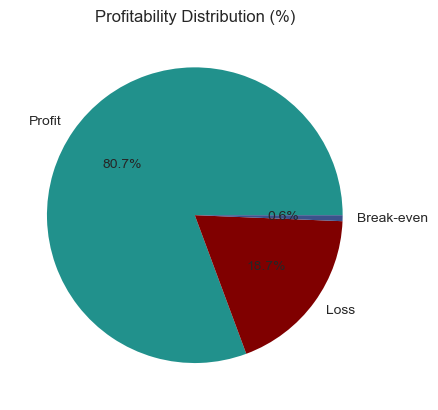

In [111]:
# visualization of profitability distribution
profit_counts = df['Profitability Flag'].value_counts(normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [112]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df = df[df['Delays'] > 0]

metrics = {}

metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delays'].quantile(0.90)
metrics['On Time Delivery %'] = (1 - metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = (metrics['Late Deliveries'] / metrics['Total Orders']) * 100
metrics['Total Profit'] = format_func(
    df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum()
)
metrics['Total Loss due to Delays'] = format_func(
    df.loc[df['Delays'] > 0, 'Order Profit Per Order'].sum()
)

print("\n---- Business KPIs ----\n")

for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


---- Business KPIs ----

Total Orders: 172765
Late Deliveries: 13242
90% Delay (days): 3.00
On Time Delivery %: 92.34
Late Delivery %: 7.66
Total Profit: 7.5M $
Total Loss due to Delays: 278.9K $


Profitability VS Delivery Time Analysis


In [113]:
profit_metrics = (
    df.groupby('Delays') ['Order Profit Per Order']
      .agg(
          mean_profit='mean',
          total_profit='sum',
          order_count='count'
      )
      .reset_index()
)

In [114]:
profit_metrics

,Delays,mean_profit,total_profit,order_count
0,-2.0,22.346853,31598.449873,1414
1,-1.0,27.178147,54410.650164,2002
2,0.0,22.358683,77070.380160,3447
3,1.0,22.070449,126309.179649,5723
4,2.0,18.219024,94830.019929,5205
5,3.0,25.006053,26356.380088,1054
6,4.0,24.913048,31390.440026,1260


In [115]:
delay_distribution = (
    df['Delays']
    .value_counts(normalize=True)
    .sort_index() *100
).reset_index()

In [116]:
delay_distribution

,Delays,proportion
0,-2.0,7.033076
1,-1.0,9.957722
2,0.0,17.144989
3,1.0,28.465556
4,2.0,25.889082
5,3.0,5.242477
6,4.0,6.267098



Profit Metrics by Delay Day:


,Delays,mean_profit,total_profit,order_count
0,-2.0,22.3,31598.4,1414
1,-1.0,27.2,54410.7,2002
2,0.0,22.4,77070.4,3447
3,1.0,22.1,126309.2,5723
4,2.0,18.2,94830.0,5205
5,3.0,25.0,26356.4,1054
6,4.0,24.9,31390.4,1260



Delay Distribution (%):


,Delay_Days,Percentage
0,-2.0,7.033076
1,-1.0,9.957722
2,0.0,17.144989
3,1.0,28.465556
4,2.0,25.889082
5,3.0,5.242477
6,4.0,6.267098


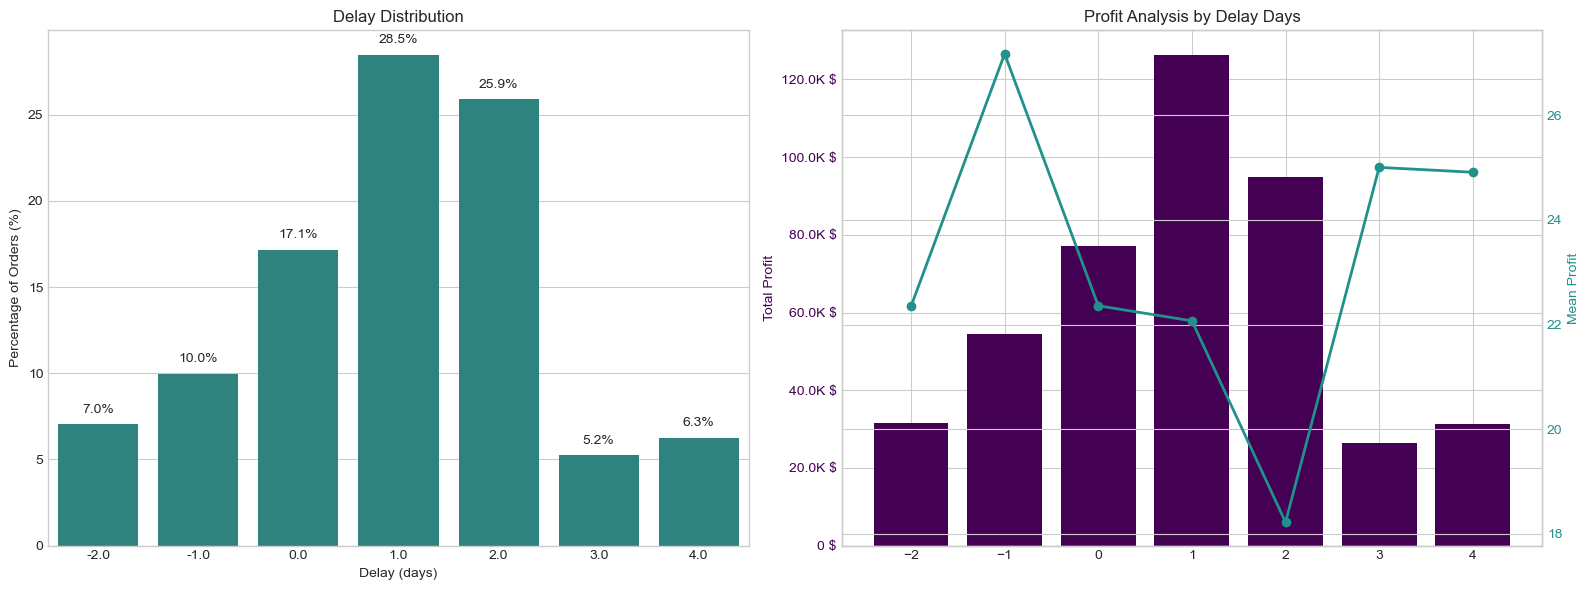

In [117]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# Rename columns for delay distribution
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# -------------------------
# Delay Distribution Plot
# -------------------------
sns.barplot(
    x='Delay_Days',
    y='Percentage',
    data=delay_distribution,
    color=accent_color,
    ax=ax1
)

ax1.set_title("Delay Distribution")
ax1.set_xlabel("Delay (days)")
ax1.set_ylabel("Percentage of Orders (%)")

# Add percentage labels
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha="center",
        va="bottom"
    )

# -------------------------
# Profit Analysis Plot
# -------------------------
ax2.set_ylabel("Total Profit", color=primary_color)

ax2.bar(
    profit_metrics['Delays'],
    profit_metrics['total_profit'],
    color=primary_color,
    label="Total Profit"
)

ax2.tick_params(axis='y', labelcolor=primary_color)

# Second Y-axis
ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color=accent_color)

ax3.plot(
    profit_metrics['Delays'],
    profit_metrics['mean_profit'],
    marker='o',
    color=accent_color,
    linewidth=2,
    label="Mean Profit"
)

ax3.tick_params(axis='y', labelcolor=accent_color)

# Format currency axis
def format_func(value, tick_number):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

ax2.yaxis.set_major_formatter(ticker.FuncFormatter(format_func))

ax2.set_title("Profit Analysis by Delay Days")

plt.tight_layout()
plt.show()

#Bottleneck Detection


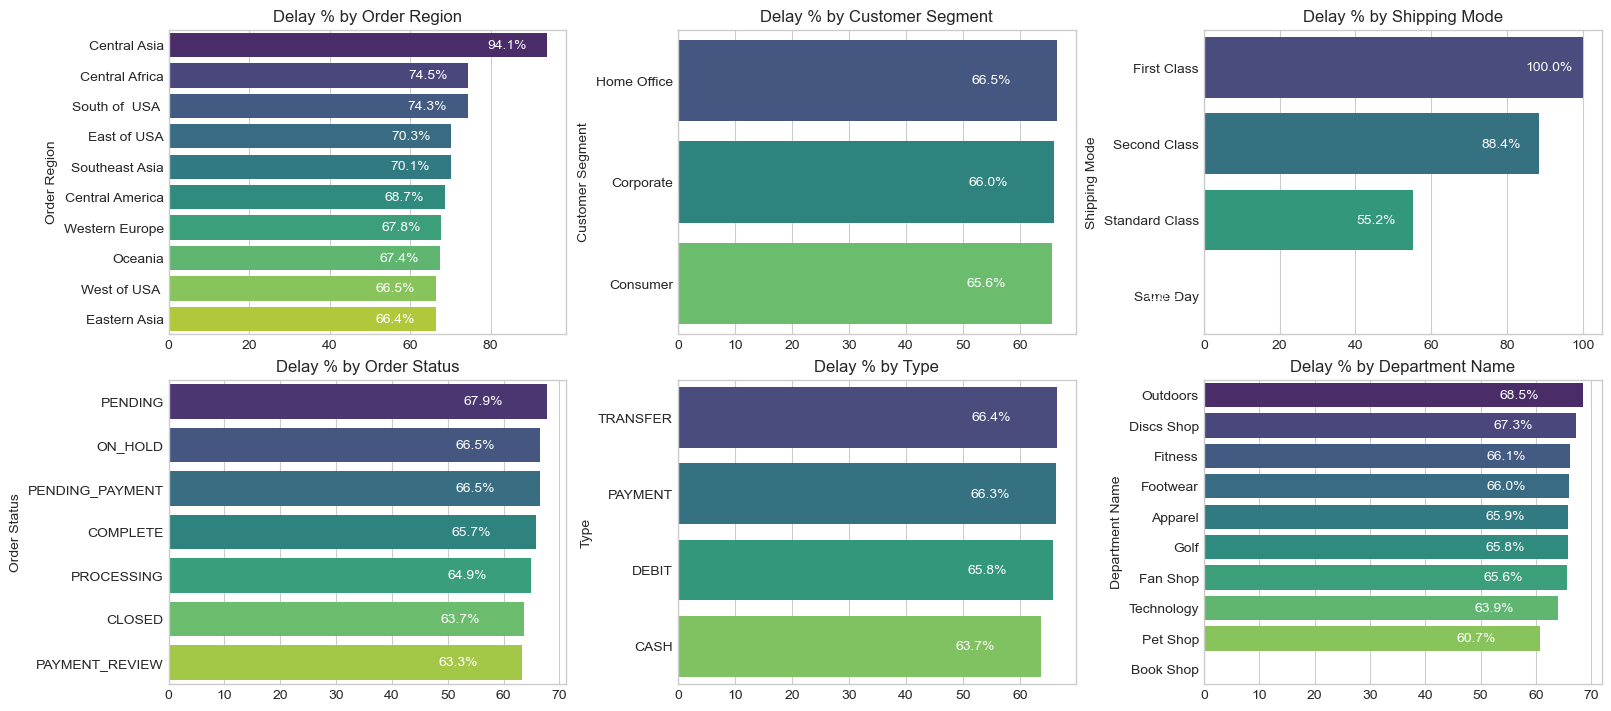

In [118]:
#Bottleneck Detection
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delays', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()

    cat_df['delay_pct'] = (
        cat_df['late_orders'] / cat_df['total_orders']
    ) * 100

    cat_df = cat_df.sort_values(
        'delay_pct',
        ascending=False
    ).head(10)

    return cat_df


categories = [
    'Order Region',
    'Customer Segment',
    'Shipping Mode',
    'Order Status',
    'Type',
    'Department Name'
]

fig, axes = plt.subplots(
    2, 3,
    figsize=(16, 7),
    constrained_layout=True
)

axes = axes.flatten()

for ax, category in zip(axes, categories):

    cat_df = compute_delay_pct_by_category(category)

    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category,
        ax=ax,
        palette='viridis'
    )

    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)

    for i, row in cat_df.reset_index().iterrows():
        ax.text(
            row['delay_pct'] - 15,
            i,
            f"{row['delay_pct']:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

plt.show()

Root Cause Analysis

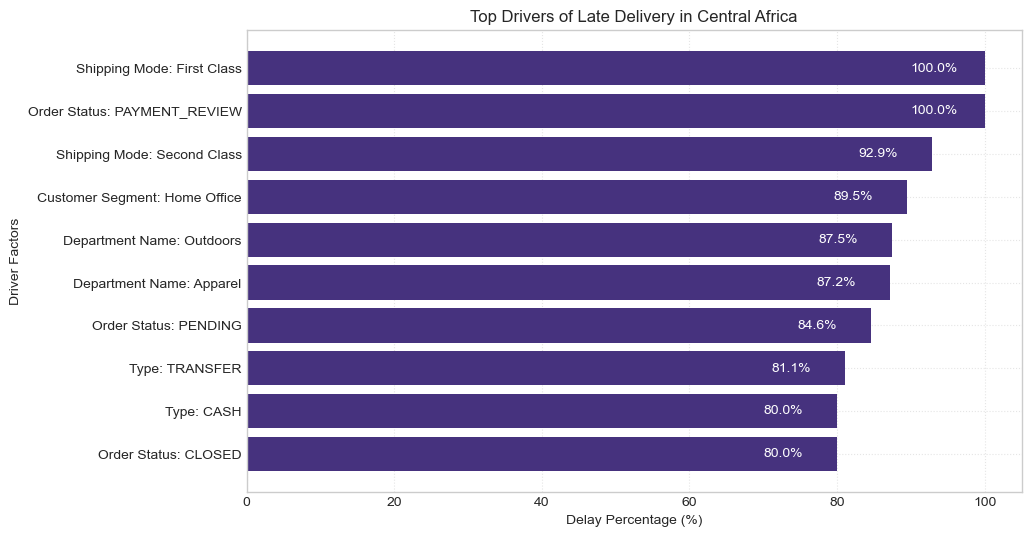

In [119]:
import pandas as pd
import matplotlib.pyplot as plt

# Top drivers of late delivery by region
def top_drivers_for_region(region):
    df_region = df[df['Order Region'] == region].copy()

    drivers = ['Shipping Mode', 'Customer Segment', 'Department Name', 'Type', 'Order Status']

    all_factors = []

    for factor in drivers:
        temp = (
            df_region.groupby(factor)
            .agg(
                total_orders=('Delays', 'count'),
                late_orders=('Is_Delayed', 'sum'),
                avg_delay=('Delays', 'mean')
            )
            .reset_index()
        )

        temp['delay_pct'] = temp['late_orders'] / temp['total_orders'] * 100
        temp['Driver'] = factor
        temp['Factor_Level'] = factor + ": " + temp[factor].astype(str)

        all_factors.append(
            temp[['Driver', 'Factor_Level', 'delay_pct', 'avg_delay', 'total_orders']]
        )

    # Combine all drivers
    final_df = pd.concat(all_factors)

    # Top 10 drivers
    top_factors = final_df.sort_values('delay_pct', ascending=False).head(10)

    plt.figure(figsize=(10, 6))

    bars = plt.barh(
        top_factors['Factor_Level'],
        top_factors['delay_pct']
    )

    plt.xlabel("Delay Percentage (%)")
    plt.ylabel("Driver Factors")
    plt.title(f"Top Drivers of Late Delivery in {region}")
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.gca().invert_yaxis()

    for bar in bars:
        width = bar.get_width()
        plt.text(
            width - 10,
            bar.get_y() + bar.get_height() / 2,
            f"{width:.1f}%",
            va='center',
            fontsize=10,
            color='white'
        )

    plt.show()


# Example usage
top_drivers_for_region('Central Africa')

Time Based Analysis

In [120]:
# Delay % by Month, Day of Week, Hour

delay_by_month = (
    df.groupby('order_month')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_month['Delays'] = delay_by_month['Is_Delayed'] * 100

delay_by_day = (
    df.groupby('order_day')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_day['Delays'] = delay_by_day['Is_Delayed'] * 100

delay_by_hour = (
    df.groupby('order_hour')['Is_Delayed']
    .mean()
    .reset_index()
)
delay_by_hour['Delays'] = delay_by_hour['Is_Delayed'] * 100

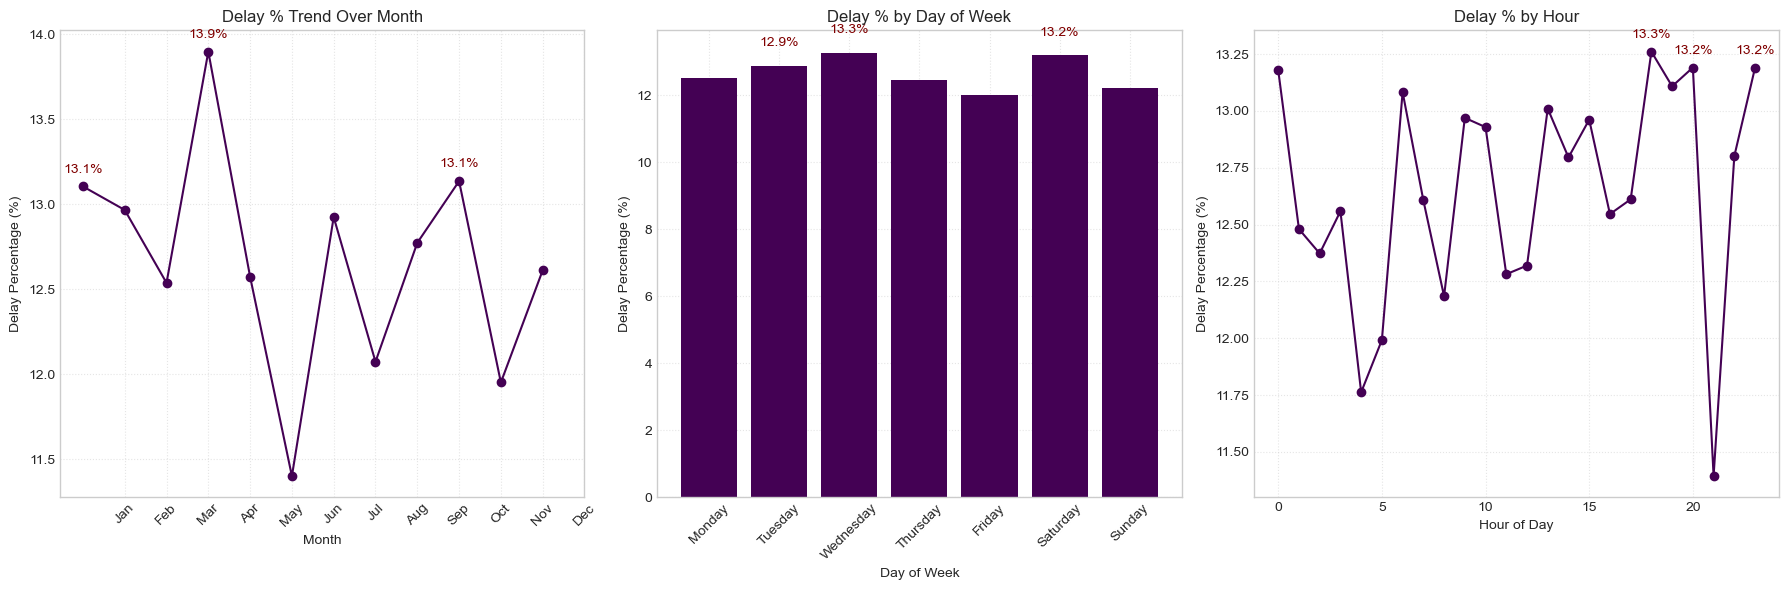

In [121]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Subplot 1: Delay % Trend Over Month
ax1.plot(delay_by_month['order_month'], delay_by_month['Delays'], marker='o', color=primary_color)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
ax1.set_xlabel("Month")
ax1.set_ylabel("Delay Percentage (%)")
ax1.set_title("Delay % Trend Over Month")
ax1.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_month = delay_by_month.nlargest(3, 'Delays')
for _, row in top3_month.iterrows():
    ax1.annotate(f"{row['Delays']:.1f}%", (row['order_month'], row['Delays']),
                 textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=10, color=danger_color)

# Subplot 2: Delay % by Day of Week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
delay_by_day['order_day'] = pd.Categorical(delay_by_day['order_day'],
                                           categories=day_order,
                                           ordered=True)
delay_by_day = delay_by_day.sort_values('order_day')

ax2.bar(delay_by_day['order_day'], delay_by_day['Delays'], color=primary_color)
ax2.set_xticklabels(delay_by_day['order_day'], rotation=45)
ax2.set_xlabel("Day of Week")
ax2.set_ylabel("Delay Percentage (%)")
ax2.set_title("Delay % by Day of Week")
ax2.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest bars
top3_day = delay_by_day.nlargest(3, 'Delays')
for _, row in top3_day.iterrows():
    height = row['Delays']
    ax2.text(row['order_day'], height + 0.5, f"{height:.1f}%",
             ha='center', va='bottom',
             fontsize=10, color=danger_color)

# Subplot 3: Delay % by Hour
ax3.plot(delay_by_hour['order_hour'], delay_by_hour['Delays'],
         marker='o', color=primary_color)
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Delay Percentage (%)")
ax3.set_title("Delay % by Hour")
ax3.grid(True, linestyle=':', alpha=0.5)

# Annotate top 3 highest
top3_hour = delay_by_hour.nlargest(3, 'Delays')
for _, row in top3_hour.iterrows():
    ax3.annotate(f"{row['Delays']:.1f}%",
                 (row['order_hour'], row['Delays']),
                 textcoords="offset points",
                 xytext=(0, 10),
                 ha='center',
                 fontsize=10,
                 color=danger_color)

plt.tight_layout()
plt.show()

Machine Learning Modeling

In [122]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, classification_report
from sklearn.ensemble import RandomForestClassifier 
from collections import Counter
from imblearn.over_sampling import SMOTE

In [123]:
X = df[[
    'Type',
    'Category Name',
    'Customer Segment',
    'Department Name',
    'Order Region',
    'Shipping Mode',
    'order_month',
    'order_hour'
]]

y = df['Late_delivery_risk']

In [124]:
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
print('Categorical columns:', cat_cols)

# Frequency encoding
for col in cat_cols:
    freq = X[col].value_counts(normalize=True)
    X[f'{col}_freq'] = X[col].map(freq)

# Keep numeric columns + new encoded features
X_encoded = X.drop(columns=cat_cols)
print('Shape after freq+target encoding:', X_encoded.shape)

X = X_encoded

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Categorical columns: ['Type', 'Category Name', 'Customer Segment', 'Department Name', 'Order Region', 'Shipping Mode', 'order_month']
Shape after freq+target encoding: (172765, 8)


In [125]:
y

0         0
1         1
2         0
3         0
4         0
         ..
180514    0
180515    1
180516    1
180517    0
180518    0
Name: Late_delivery_risk, Length: 172765, dtype: int64

In [126]:
y.value_counts()

Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

In [131]:
from imblearn.over_sampling import SMOTE
from collections import Counter
import numpy as np

# Check for infinite values
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.fillna(X_train.median())

print("Before balancing:", Counter(y_train))

smote = SMOTE(random_state=42, k_neighbors=5)

X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("After balancing:", Counter(y_train_bal))

Before balancing: Counter({1: 79182, 0: 59030})
After balancing: Counter({0: 79182, 1: 79182})


In [132]:
print(X_train.isnull().sum().sum())   # Total missing values in X_train
print(y_train.isnull().sum())         # Missing values in y_train

0
0


In [133]:
from collections import Counter

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nClass Distribution:")
print(Counter(y_train))

print("\nData Types:")
print(X_train.dtypes.value_counts())

print("\nObject Columns:")
print(X_train.select_dtypes(include=['object']).columns.tolist())

X_train shape: (138212, 8)
y_train shape: (138212,)

Class Distribution:
Counter({1: 79182, 0: 59030})

Data Types:
float64    8
Name: count, dtype: int64

Object Columns:
[]


In [134]:
def evaluate_model(y_true, y_pred, model_name):
    print(f"\n--- {model_name} ---")
    print("Accuracy:", round(accuracy_score(y_true, y_pred),2))
    print("Precision:", round(precision_score(y_true,y_pred),2))
    print("Recall:", round(recall_score(y_true, y_pred),2))
    print("\nClassification report:\n", classification_report(y_true,y_pred))

In [135]:
#fit the random Forest model on balanced data
rf_model_balanced = RandomForestClassifier(random_state=42)
rf_model_balanced.fit(X_train_bal, y_train_bal)

y_pred_rf_balanced = rf_model_balanced.predict(X_test)
evaluate_model(y_test, y_pred_rf_balanced, "Random Forest Classifier")


--- Random Forest Classifier ---
Accuracy: 0.73
Precision: 0.8
Recall: 0.7

Classification report:
               precision    recall  f1-score   support

           0       0.66      0.77      0.71     14758
           1       0.80      0.70      0.75     19795

    accuracy                           0.73     34553
   macro avg       0.73      0.73      0.73     34553
weighted avg       0.74      0.73      0.73     34553

